In [1]:
%pwd

'/home/arno/Projects/Pint3D/print_ngp/mylut/printImg'

In [2]:
import qrcode
from PIL import Image
import os
import numpy as np
import sys

sys.path.append("/home/arno/Projects/Pint3D/print_ngp/util")
import printer.printerICM as icm
import printer.printerHelper as printerHelper

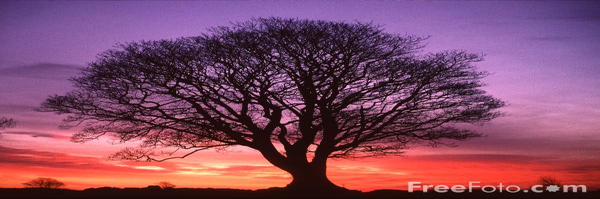

In [3]:
resizeImg=printerHelper.resize_byVoxelSize("data/2.jpg", None)
resizeImg

In [7]:

# 首先把sRGB的图片利用打印机的icc文件转换为CMYK的图片
ims=icm.convert_color_profile(resizeImg, output_mode="CMYK", save_files=False,
                                  srgb_profile_path = "/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/AdobeRGB1998.icc", 
                                  cmyk_profile_path = "/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/Stratasys_J8_7xx_VeroUltraWhite_HT3_VividCMYK.icm",)

cmykHalftoneImgs=[]
for transferMode in range(4):
    im=ims[transferMode]
    cmyk= im.split()         # RGB contone RGB to CMYK contone
    c = cmyk[0].convert('1').convert('L')    # and then halftone ('1') each plane
    m = cmyk[1].convert('1').convert('L')    # ...and back to ('L') mode
    y = cmyk[2].convert('1').convert('L')
    k = cmyk[3].convert('1').convert('L')

    new_cmyk = Image.merge('CMYK',[c,m,y,k]) # put together all 4 planes
    new_cmyk.save(f"data/tree_CMYK_{transferMode}_halftone_simpleL.tif")           # and save to file
    cmykHalftoneImgs.append(new_cmyk)

 ~~色彩分离（超分）~~ 超分不对，应该采样

In [124]:
import numpy as np
from PIL import Image
import random

def separate_colors(pixel):
    """将一个CMYK像素分解为基础色"""
    c, m, y, k = pixel
    base_colors = []
    
    # 添加基础色
    if c == 255: base_colors.append([255,0,0,0])  # C
    if m == 255: base_colors.append([0,255,0,0])  # M
    if y == 255: base_colors.append([0,0,255,0])  # Y
    if k == 255: base_colors.append([0,0,0,255])  # K
    
    # 如果没有任何颜色，返回白色
    if not base_colors:
        return [[0,0,0,0]] * 4
    
    # 如果基础色少于4个，重复填充
    while len(base_colors) < 4:
        base_colors.append(random.choice(base_colors))
    
    # 随机打乱顺序
    random.shuffle(base_colors)
    return base_colors

def upsample_cmyk_image(image):
    """将CMYK图像进行4倍超分离"""
    width, height = image.size
    # 创建新图像，尺寸是原来的2倍
    new_image = Image.new('CMYK', (width*2, height*2))
    img_array = np.array(image)
    
    for y in range(height):
        for x in range(width):
            # 获取原始像素的CMYK值
            pixel = img_array[y,x]
            # 分解为基础色
            separated_colors = separate_colors(pixel)
            
            # 在2x2区域填充分离后的颜色
            for i, color in enumerate(separated_colors):
                new_x = (x * 2) + (i % 2)
                new_y = (y * 2) + (i // 2)
                new_image.putpixel((new_x, new_y), tuple(color))
    
    return new_image

CMYK_halftone_simpleL_separated_imgs=[]
# 处理所有图片
for transferMode in range(4):
    im=cmykHalftoneImgs[transferMode]
    upsampled_img = upsample_cmyk_image(im)
    upsampled_img.save(f"data/tree_CMYK_{transferMode}_halftone_simpleL_separated.tif")
    CMYK_halftone_simpleL_separated_imgs.append(upsampled_img)


add qrcode

In [133]:
from PIL import ImageDraw, ImageFont

def add_qr_to_image(original_img, url, text="", qr_size=200, margin=10):
    # 生成二维码
    qr_code = create_qr_code(url, qr_size)
    
    # 获取原图尺寸
    orig_width, orig_height = original_img.size
    
    # 创建新的更大画布，增加高度以容纳文字
    new_width = orig_width + qr_size + margin
    new_height = max(orig_height, qr_size + margin + 30)
    
    # 创建新的白色背景图片
    new_image = Image.new('CMYK', (new_width, new_height), 'white')
    
    # 粘贴原图到左侧
    new_image.paste(original_img, (0, 0))
    
    # 粘贴二维码到右上角
    new_image.paste(qr_code, (orig_width + margin, margin))
    
    # 添加文字
    if text:
        text_img = Image.new('RGB', ( orig_height, qr_size + margin), 'white')
        
        draw = ImageDraw.Draw(text_img)
        font = ImageFont.load_default()
        draw.text((10,10), text, fill='black', font=font, spacing=20)
        text_img=text_img.rotate(-90, expand=True)
        
        text_img = text_img.convert('CMYK')
        cmyk= text_img.split()         # RGB contone RGB to CMYK contone
        c = cmyk[0].convert('1').convert('L')    # and then halftone ('1') each plane
        m = cmyk[1].convert('1').convert('L')    # ...and back to ('L') mode
        y = cmyk[2].convert('1').convert('L')
        k = cmyk[3].convert('1').convert('L')

        text_img = Image.merge('CMYK',[c,m,y,k]) # put together all 4 planes
    
    
        new_image.paste(text_img, (orig_width + margin, margin+ 50))
    
    return new_image

# 使用示例：
for transferMode in range(4):
    im=CMYK_halftone_simpleL_separated_imgs[transferMode]
    url =f"https://gist.github.com/arnoliudaxia/ed41d50129cc09960c4caed819882b6e#file-simplehalftone-ipynb"
    text = f"iccMode={transferMode} color2mm_White1mm Algorithms: simpleHalftone.ipynb"  # 添加您想要显示的文字
    result = add_qr_to_image(im, url, text=text, qr_size=50, margin=1)
    
    result.save(f"data/tree_CMYK_{transferMode}_halftone_simpleL_qr_separated.tif")

~~接下来只需要复制层就好~~ 每一层其实应该不一样

In [135]:
import shutil

z = 0.014
ZExpandTimes2OneMM=int(1/z)
# 1mm的颜色和1mm的纯白
for mode in range(4):
    os.system(f"/home/arno/conda/envs/print3DNerfCUDA124/bin/python /home/arno/Projects/Pint3D/print_ngp/util/checkPrintfile.py data/tree_CMYK_{mode}_halftone_simpleL_qr_separated.tif")
    
    img = Image.open(f"data/tree_CMYK_{mode}_halftone_simpleL_qr_separated.tif")
    img_array = np.array(img)
    expanded_img_array = np.expand_dims(img_array, axis=0)
    tiled_img_array = np.tile(expanded_img_array, (ZExpandTimes2OneMM*2, 1, 1, 1))
    # 创建一个与 tiled_img_array 形状相同的数组，值全为1
    ones_array = np.ones_like(tiled_img_array)
    # 在第一个轴上拼接两个数组
    concatenated_array = np.concatenate((tiled_img_array, ones_array), axis=0)

    BaseFolder=f"print/color2mm_White1mm/mode{mode}"
    if os.path.exists(BaseFolder):
        shutil.rmtree(BaseFolder)
    os.makedirs(BaseFolder, exist_ok=True)
    np.save(f"{BaseFolder}/array.npy", concatenated_array)

    os.makedirs(f"{BaseFolder}/slice", exist_ok=True)
    # 遍历第一个维度的每个切片
    for i in range(concatenated_array.shape[0]):
        # 获取第i个切片
        slice_2d = concatenated_array[i]
        
        # 创建一个PIL图像对象
        img = Image.fromarray(slice_2d, 'CMYK')
        img=img.convert('RGB')
        # img = Image.fromarray(slice_2d, 'RGB')
        
        # 保存为PNG文件
        # img.save(f"print/color1mm_White1mm/slice/slice_{i}.tif")
        img.save(f"{BaseFolder}/slice/slice_{i}.png")

    print("All slices have been saved as PNG files.")

颜色数量正确
x: 105.08 mm, y: 22.40 mm
All slices have been saved as PNG files.
颜色数量正确
x: 105.08 mm, y: 22.40 mm
All slices have been saved as PNG files.
颜色数量正确
x: 105.08 mm, y: 22.40 mm
All slices have been saved as PNG files.
颜色数量正确
x: 105.08 mm, y: 22.40 mm
All slices have been saved as PNG files.
